# Telegram EDA & Feature Engineering (v2)

Merged, end-to-end version of `eda_telegram.ipynb` + `eda_telegram_text_features.ipynb`.

**Scope of kept feature engineering:** region tagging, sentence embeddings, and PCA retaining >=95% of variance. The original 15-token and expanded 150-token `CountVectorizer` bag-of-words and the bilingual `kw_*` keyword-group counters are dropped. Basic hourly aggregates (`messages_count`, `has_threat_sum`, rolling windows, `threat_diff_1h`) are kept as foundational features. Lemmatization is kept too -- not as a feature column, but as the text-cleaning step the embeddings are computed on. The baseline-pipeline re-run and the uk/ru keyword-coverage check are kept for full narrative context.

Sections:
1. Imports & setup
2. Load raw data
3. Baseline pipeline re-run (production code, DST-safety patch)
4. Language-mix check (uk vs ru)
5. Region gazetteer (Phase 1)
6. Row-level cleaning & region tagging across the corpus
7. Exploratory Data Analysis
8. Lemmatization (Phase 2, feeds the embeddings below)
9. National hourly feature table
10. Semantic embeddings + PCA (95% variance)
11. Leakage-prevention shift
12. Save prepared datasets
13. Results / Conclusion

In [1]:
import os
import re
import sys
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymorphy3 import MorphAnalyzer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings("ignore")

# repo root must be cwd (and on sys.path) before importing app.* -- telegram_features.py
# loads a joblib artifact at module import time (VECTORIZER = joblib.load(...))
if os.path.basename(os.getcwd()) == "eda":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from app.core.features.telegram_features import (
    clean_text as baseline_clean_text,
    has_threat as baseline_has_threat,
    STOP_WORDS as BASELINE_STOP_WORDS,
    THREAT_KEYWORDS as BASELINE_THREAT_KEYWORDS,
    preprocess_messages,
    _parse_and_clean_dates,
    _drop_missing_and_duplicates,
    _add_time_features,
    _add_text_length,
    _apply_text_pipeline,
    _add_nlp_features,
    _add_rolling_features,
    TIMEZONE,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
SEED = 7
np.random.seed(SEED)
os.getcwd()

'C:\\PythonProjects\\AlarmForecast'

# Load raw data

In [2]:
tg_raw = pd.read_csv("data/telegram/telegram_data.csv")
print("raw rows (incl. empty text):", tg_raw.shape[0])
tg_raw.head(3)

raw rows (incl. empty text): 385114


,id,date,text
0,5002,2022-02-24 00:02:34+00:00,⚡️**Совбез ООН проведёт экстренное заседание п...
1,5003,2022-02-24 02:59:41+00:00,Путин прямо сейчас заявил о начале проведения ...
2,5004,2022-02-24 03:00:29+00:00,❗️**Военная операция в Донбассе начинается — з...


## Baseline pipeline re-run (production code)

`preprocess_messages()` (imported above, unchanged) is the current production pipeline. We run it once, as a DST-safety-patched copy, to get a concrete "before" baseline to improve on.

**Note:** `preprocess_messages(tg_raw)` crashes on the full history -- `_build_hourly_dataframe()` (`telegram_features.py`) does `df["date"].dt.floor("h")` on tz-aware Europe/Kyiv timestamps, and pandas defaults to raising on the Oct-2022 DST fall-back (03:00-03:59 occurs twice that night). This is a real, previously-unhit production bug -- likely never triggered because production reprocesses recent windows, not the full 2022-2026 history in one call. Not fixed in `telegram_features.py` itself (out of scope here); reproduced with only that one step patched (`ambiguous="NaT"` drops the handful of ambiguous hours).

In [3]:
def _build_hourly_dataframe_dst_safe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hour_rounded"] = df["date"].dt.floor("h", ambiguous="NaT", nonexistent="shift_forward")
    df = df.dropna(subset=["hour_rounded"])

    hourly = (
        df.groupby("hour_rounded")
        .agg(
            messages_count=("text", "count"),
            has_threat_sum=("has_threat_keyword", "sum"),
            combined_text=("clean_text", lambda x: " ".join(x)),
        )
        .reset_index()
    )
    full_range = pd.date_range(
        start=hourly["hour_rounded"].min(),
        end=pd.Timestamp.now(tz=TIMEZONE).floor("h"),
        freq="h",
        tz=TIMEZONE,
    )
    return (
        hourly.set_index("hour_rounded")
        .reindex(full_range)
        .fillna({"messages_count": 0, "has_threat_sum": 0, "combined_text": ""})
        .reset_index()
        .rename(columns={"index": "datetime"})
    )


def preprocess_messages_dst_safe(df, vectorizer=None, fit_vectorizer=True):
    df = _parse_and_clean_dates(df)
    df = _drop_missing_and_duplicates(df)
    df = _add_time_features(df)
    df = _add_text_length(df)
    df = _apply_text_pipeline(df)
    hourly = _build_hourly_dataframe_dst_safe(df)
    hourly, vectorizer = _add_nlp_features(hourly, vectorizer, fit_vectorizer)
    hourly = _add_rolling_features(hourly)
    return hourly, vectorizer


baseline_hourly, baseline_vectorizer = preprocess_messages_dst_safe(tg_raw, fit_vectorizer=True)

nlp_cols = [c for c in baseline_hourly.columns if c.startswith("nlp_")]
print("baseline hourly shape:", baseline_hourly.shape)
print(f"baseline NLP_MAX_FEATURES vocabulary ({len(nlp_cols)} cols):", nlp_cols)
print("hours with any threat keyword hit:", (baseline_hourly["has_threat_sum"] > 0).mean().round(3))
baseline_hourly.head(3)

baseline hourly shape: (38756, 21)
baseline NLP_MAX_FEATURES vocabulary (15 cols): ['nlp_артобстрілу', 'nlp_бпла', 'nlp_відбій', 'nlp_відбій_тривоги', 'nlp_дніпропетровська', 'nlp_донецька', 'nlp_запорізька', 'nlp_нікополь', 'nlp_нікополь_нікопольська', 'nlp_нікопольська', 'nlp_повітряна', 'nlp_повітряна_тривога', 'nlp_тривога', 'nlp_тривоги', 'nlp_харківська']
hours with any threat keyword hit: 0.612


,datetime,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h
0,2022-02-24 02:00:00+02:00,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,0.0
1,2022-02-24 03:00:00+02:00,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,0.0
2,2022-02-24 04:00:00+02:00,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,2.0,0.0


## Language-mix check (uk vs ru)

The current gazetteer/keywords/lemmatizer are all Ukrainian-only. The very first messages in the dataset (2022-02-24) are almost entirely Russian-language, which could mean the whole corpus is poorly served by a uk-only pipeline. We measure this directly: for every message, does an existing Ukrainian threat keyword match, does its Russian translation match, and how many messages would the Russian keyword catch that the Ukrainian one misses?

rows with non-null text: 357065


uk keyword hit                    22.8%
ru keyword hit                    12.4%
ru hit, uk missed (blind spot)     0.3%
dtype: str


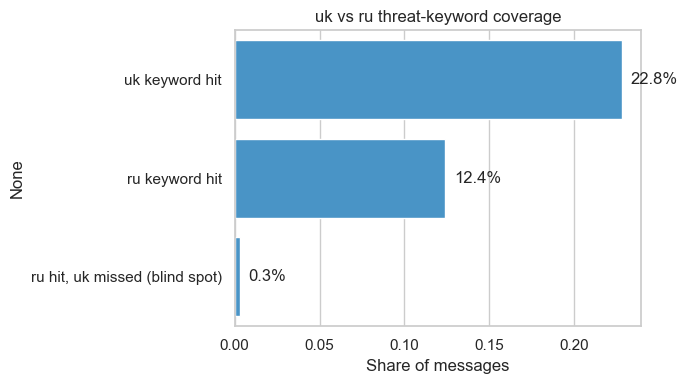

In [4]:
tg_raw_nonempty = tg_raw.dropna(subset=["text"])
print("rows with non-null text:", tg_raw_nonempty.shape[0])

RU_THREAT_KEYWORDS = [
    "пуск", "вылет", "баллист", "мопед", "шахед", "ракет",
    "укрыт", "внимани", "взлет", "миг", "кинжал", "бпла", "угроз",
]

text_lower = tg_raw_nonempty["text"].astype(str).str.lower()
uk_hit = text_lower.apply(lambda t: any(k in t for k in BASELINE_THREAT_KEYWORDS))
ru_hit = text_lower.apply(lambda t: any(k in t for k in RU_THREAT_KEYWORDS))

coverage = pd.Series({
    "uk keyword hit": uk_hit.mean(),
    "ru keyword hit": ru_hit.mean(),
    "ru hit, uk missed (blind spot)": (ru_hit & ~uk_hit).mean(),
})
print(coverage.apply(lambda x: f"{x:.1%}"))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=coverage.values, y=coverage.index, color="#3498db", ax=ax)
for i, v in enumerate(coverage.values):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center")
ax.set_xlabel("Share of messages")
ax.set_title("uk vs ru threat-keyword coverage")
plt.tight_layout()
plt.show()

## Region gazetteer (Phase 1)

`regions.csv` gives us `region_id` and the Ukrainian oblast name (`region`, e.g. "Харківська обл."). Nobody writes that in a Telegram message -- they write "у Харкові" or "Харків". So per `region_id` we curate:
- the oblast-name stem ("харківськ" from "Харківська обл."),
- the known Cyrillic city name(s) for that region (hand-curated -- `regions.csv` only has an English `city` column, not useful for matching Cyrillic text),
- `pymorphy3` case-form generation on top, so one canonical name expands to its inflected forms automatically instead of being hand-typed per case.

In [5]:
regions_df = pd.read_csv("data/alarms/regions.csv")

# Hand-curated city aliases per region_id: uk spelling + common ru spelling.
# region_id 14 (Kyiv OBLAST) has no city of its own -- its administrative
# center is Kyiv CITY, which is the separate region_id 31. We seed a few
# distinct Kyiv-oblast towns instead of a capital city.
REGION_CITY_ALIASES: dict[int, list[str]] = {
    3: ["хмельницький", "хмельницкий"], 4: ["вінниця", "винница"],
    5: ["рівне", "ровно"], 8: ["луцьк", "луцк"],
    9: ["дніпро", "дніпропетровськ", "днепр", "днепропетровск"],
    10: ["житомир"], 11: ["ужгород"], 12: ["запоріжжя", "запорожье"],
    13: ["івано-франківськ", "ивано-франковск"],
    14: ["бровари", "бровары", "ірпінь", "ирпень", "буча",
         "біла церква", "белая церковь", "васильків", "васильков"],
    15: ["кропивницький", "кропивницкий", "кіровоград", "кировоград"],
    16: ["луганськ", "луганск", "сєвєродонецьк", "северодонецк"],
    17: ["миколаїв", "николаев"], 18: ["одеса", "одесса"],
    19: ["полтава"], 20: ["суми", "сумы"], 21: ["тернопіль", "тернополь"],
    22: ["харків", "харьков"], 23: ["херсон"], 24: ["черкаси", "черкассы"],
    25: ["чернігів", "чернигов"], 26: ["чернівці", "черновцы"],
    27: ["львів", "львов"], 28: ["донецьк", "донецк", "краматорськ", "краматорск"],
    31: ["київ", "киев"],
}


def oblast_adjective(region_name: str) -> str | None:
    """'Харківська обл.' -> 'харківська' (the bare adjective, still inflectable
    by pymorphy3); None for non-oblast rows like region_id 31's bare 'Київ'."""
    name = region_name.strip().lower()
    if not name.endswith(" обл."):
        return None
    return name[: -len(" обл.")]


regions_df["oblast_adjective"] = regions_df["region"].apply(oblast_adjective)
regions_df[["region_id", "region", "oblast_adjective"]]

,region_id,region,oblast_adjective
0,3,Хмельницька обл.,хмельницька
1,4,Вінницька обл.,вінницька
2,5,Рівненська обл.,рівненська
3,8,Волинська обл.,волинська
4,9,Дніпропетровська обл.,дніпропетровська
5,10,Житомирська обл.,житомирська
6,11,Закарпатська обл.,закарпатська
7,12,Запорізька обл.,запорізька
8,13,Івано-Франківська обл.,івано-франківська
9,14,Київська обл.,київська


In [6]:
morph_uk = MorphAnalyzer(lang="uk")
morph_ru = MorphAnalyzer(lang="ru")


@lru_cache(maxsize=None)
def case_forms(word: str, lang: str) -> set[str]:
    """All case/number inflections pymorphy3 knows for *word* (nom. included).
    Multi-word phrases (e.g. 'біла церква') aren't inflected -- returned as-is."""
    if " " in word or "-" in word:
        return {word}
    morph = morph_uk if lang == "uk" else morph_ru
    parse = morph.parse(word)[0]
    return {f.word for f in parse.lexeme} | {word}


# Colloquial "-щина"/historical-region oblast nicknames ("харківщина", "київщина", ...)
# are NOT regular suffix derivations (Донецьк -> Донеччина, not "донецщина";
# Закарпаття is a wholly different word), so hand-curated like REGION_CITY_ALIASES.
OBLAST_NICKNAMES: dict[int, list[str]] = {
    3: ["хмельниччина"], 4: ["вінниччина"], 5: ["рівненщина"], 8: ["волинь"],
    9: ["дніпропетровщина"], 10: ["житомирщина"], 11: ["закарпаття"],
    13: ["прикарпаття"], 14: ["київщина"], 15: ["кіровоградщина"],
    16: ["луганщина"], 17: ["миколаївщина"], 18: ["одещина"],
    19: ["полтавщина"], 20: ["сумщина"], 21: ["тернопільщина"],
    22: ["харківщина"], 23: ["херсонщина"], 24: ["черкащина"],
    25: ["чернігівщина"], 26: ["буковина"], 27: ["львівщина"], 28: ["донеччина"],
}

ALIAS_TO_REGIONS: dict[str, set[int]] = {}

for _, row in regions_df.iterrows():
    region_id = int(row["region_id"])
    forms = set()
    # oblast_adjective(...) returns None for non-oblast rows (region 31), but
    # pandas silently upcasts that None to NaN in the object column, so
    # pd.notna() is required here ("is not None" doesn't catch NaN).
    if pd.notna(row["oblast_adjective"]):
        forms |= case_forms(row["oblast_adjective"], "uk")
    for alias in REGION_CITY_ALIASES.get(region_id, []) + OBLAST_NICKNAMES.get(region_id, []):
        forms |= case_forms(alias, "uk") | case_forms(alias, "ru")
    for form in forms:
        ALIAS_TO_REGIONS.setdefault(form, set()).add(region_id)

print(f"{len(ALIAS_TO_REGIONS)} surface forms mapped across {regions_df.shape[0]} regions")
print("sample forms for Kharkiv oblast (22):", sorted(f for f, ids in ALIAS_TO_REGIONS.items() if 22 in ids)[:10])
print("forms that match >1 region_id (ambiguous):", {f: ids for f, ids in ALIAS_TO_REGIONS.items() if len(ids) > 1})

1753 surface forms mapped across 25 regions
sample forms for Kharkiv oblast (22): ['харкова', 'харкове', 'харковом', 'харкову', 'харкові', 'харків', 'харківська', 'харківське', 'харківський', 'харківським']
forms that match >1 region_id (ambiguous): {}


In [7]:
WORD_RE = re.compile(r"[а-яіїєґ'\-]+")


def tag_regions(text: str) -> set[int]:
    """Return the set of region_ids mentioned in *text* (word-level lookup
    against ALIAS_TO_REGIONS, which already folds in oblast adjectives, city
    names, and "-щина" nicknames)."""
    words = WORD_RE.findall(str(text).lower())
    matched_ids: set[int] = set()
    for w in words:
        matched_ids |= ALIAS_TO_REGIONS.get(w, set())
    return matched_ids

### Smoke test

Synthetic messages with an explicit region mention should tag exactly that `region_id`, in each surface form (nominative, locative "у Харкові", colloquial "-щина", Russian spelling).

In [8]:
smoke_tests = [
    ("Тривога у Харкові!", {22}),
    ("На Харківщині повітряна тривога", {22}),
    ("В Харькове объявлена тревога", {22}),
    ("Шахед курсом на Дніпро", {9}),
    ("Вибухи в Києві", {31}),
    ("Загроза для Київщини та Сумщини", {14, 20}),
    ("Все спокійно, відбій тривоги", set()),
]

for text, expected in smoke_tests:
    got = tag_regions(text)
    status = "OK" if got == expected else "MISMATCH"
    print(f"[{status}] {text!r} -> {got} (expected {expected})")
    assert got == expected, f"tag_regions({text!r}) = {got}, expected {expected}"

[OK] 'Тривога у Харкові!' -> {22} (expected {22})
[OK] 'На Харківщині повітряна тривога' -> {22} (expected {22})
[OK] 'В Харькове объявлена тревога' -> {22} (expected {22})
[OK] 'Шахед курсом на Дніпро' -> {9} (expected {9})
[OK] 'Вибухи в Києві' -> {31} (expected {31})
[OK] 'Загроза для Київщини та Сумщини' -> {20, 14} (expected {20, 14})
[OK] 'Все спокійно, відбій тривоги' -> set() (expected set())


## Row-level cleaning & region tagging across the corpus

Build the row-level cleaned dataframe once (`tg_rows`) -- reused by every section below (EDA, lemmatization, national hourly aggregation, embeddings) so the expensive cleaning/tagging steps run once instead of being repeated per section. Then tag every message with `tag_regions`, and build the long-format `(region_id, hour) -> region_mentions_count, region_threat_count` table -- this is what would let `merge_data.py` merge Telegram features by `["region_id", "time"]` instead of `time` alone.

In [9]:
tg_rows = _parse_and_clean_dates(tg_raw)
tg_rows = _drop_missing_and_duplicates(tg_rows)
tg_rows = _add_time_features(tg_rows)
tg_rows = _add_text_length(tg_rows)
tg_rows = _apply_text_pipeline(tg_rows)
tg_rows["hour_rounded"] = tg_rows["date"].dt.floor("h", ambiguous="NaT", nonexistent="shift_forward")
tg_rows = tg_rows.dropna(subset=["hour_rounded"])

tg_rows["region_ids"] = tg_rows["text"].apply(tag_regions)
tg_rows["n_regions_tagged"] = tg_rows["region_ids"].apply(len)

print("rows:", tg_rows.shape[0])
print("rows with >=1 region tag:", (tg_rows["n_regions_tagged"] > 0).mean().round(3))
tg_rows[["text", "region_ids", "hour_rounded"]].head(5)

rows: 356993
rows with >=1 region tag: 0.604


,text,region_ids,hour_rounded
0,⚡️**Совбез ООН проведёт экстренное заседание п...,{31},2022-02-24 02:00:00+02:00
1,Путин прямо сейчас заявил о начале проведения ...,{},2022-02-24 04:00:00+02:00
2,❗️**Военная операция в Донбассе начинается — з...,{},2022-02-24 05:00:00+02:00
3,"‼️**Вся линия фронта, очень громко. Бьют из Гр...",{},2022-02-24 05:00:00+02:00
4,В аэропорту Жуляны не регестрируют пассажиров ...,{},2022-02-24 05:00:00+02:00


In [10]:
region_long = tg_rows[["hour_rounded", "region_ids", "has_threat_keyword"]].explode("region_ids").dropna(subset=["region_ids"])
region_long = region_long.rename(columns={"region_ids": "region_id"})
region_long["region_id"] = region_long["region_id"].astype(int)

region_hourly = (
    region_long.groupby(["region_id", "hour_rounded"])
    .agg(
        region_mentions_count=("region_id", "count"),
        region_threat_count=("has_threat_keyword", "sum"),
    )
    .reset_index()
)

print("region-hour rows (only hours/regions with >=1 mention):", region_hourly.shape[0])
region_hourly.head(5)

region-hour rows (only hours/regions with >=1 mention): 152269


,region_id,hour_rounded,region_mentions_count,region_threat_count
0,3,2022-02-25 14:00:00+02:00,1,0
1,3,2022-02-26 05:00:00+02:00,1,0
2,3,2022-02-26 09:00:00+02:00,1,0
3,3,2022-02-26 17:00:00+02:00,1,0
4,3,2022-03-02 13:00:00+02:00,1,0


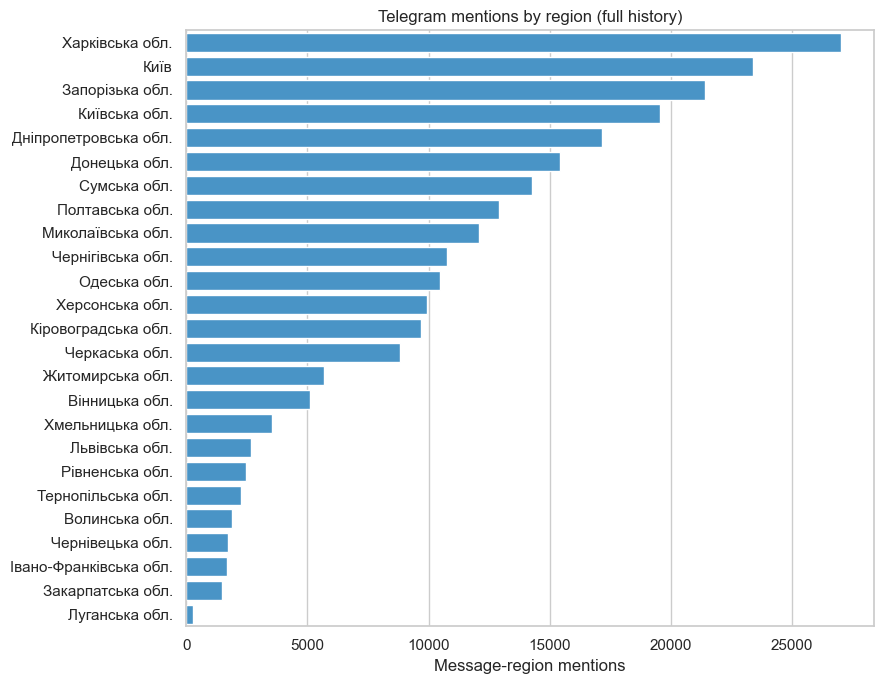

Share of messages mentioning >=1 region: 60.4%


In [11]:
top_regions = (
    region_long.groupby("region_id").size().sort_values(ascending=False)
    .rename("mentions").reset_index()
    .merge(regions_df[["region_id", "region"]], on="region_id")
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=top_regions, x="mentions", y="region", color="#3498db", ax=ax)
ax.set_title("Telegram mentions by region (full history)")
ax.set_xlabel("Message-region mentions")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Share of messages mentioning >=1 region: {(tg_rows['n_regions_tagged'] > 0).mean():.1%}")

### Cross-check against real alarms

Region tagging is only useful if it actually correlates with regional reality. We reuse `explode_by_hour()` (`app/core/features/alarms_features.py`, already handles interval-to-hourly expansion) to get real per-region alarm status per hour from `data/alarms/alarms-merged.csv`, then compare P(alarm active) when Telegram tagged that region with a threat keyword that hour vs. the unconditional base rate.

In [12]:
from app.core.features.alarms_features import explode_by_hour

alarms_raw = pd.read_csv("data/alarms/alarms-merged.csv", sep=";").rename(columns={"region_title": "region"})
alarms_raw["start"] = pd.to_datetime(alarms_raw["start"])
alarms_raw["end"] = pd.to_datetime(alarms_raw["end"])

alarm_hourly = explode_by_hour(alarms_raw)
alarm_hourly["time"] = pd.to_datetime(alarm_hourly["time"]).dt.tz_localize(
    TIMEZONE, ambiguous="NaT", nonexistent="shift_forward"
)
alarm_hourly = alarm_hourly.dropna(subset=["time"])
alarm_hourly["region_id"] = alarm_hourly["region_id"].astype(int)

# full (region_id, hour) spine over the Telegram date range, so the base rate
# reflects all region-hours -- not just the ones Telegram happened to mention.
timeline = pd.date_range(tg_rows["hour_rounded"].min(), tg_rows["hour_rounded"].max(), freq="h")
spine = pd.MultiIndex.from_product([regions_df["region_id"], timeline], names=["region_id", "hour_rounded"]).to_frame(index=False)

spine = spine.merge(
    alarm_hourly[["region_id", "time", "alarm"]].rename(columns={"time": "hour_rounded"}),
    on=["region_id", "hour_rounded"], how="left",
)
spine["alarm"] = spine["alarm"].fillna(0).astype(int)

spine = spine.merge(region_hourly, on=["region_id", "hour_rounded"], how="left")
spine[["region_mentions_count", "region_threat_count"]] = spine[["region_mentions_count", "region_threat_count"]].fillna(0)

base_rate = spine["alarm"].mean()
rate_given_mention = spine.loc[spine["region_mentions_count"] > 0, "alarm"].mean()
rate_given_threat_mention = spine.loc[spine["region_threat_count"] > 0, "alarm"].mean()

print(f"P(alarm active)                                    = {base_rate:.1%}  (base rate)")
print(f"P(alarm active | region mentioned that hour)        = {rate_given_mention:.1%}")
print(f"P(alarm active | region + threat keyword that hour) = {rate_given_threat_mention:.1%}")

P(alarm active)                                    = 18.9%  (base rate)
P(alarm active | region mentioned that hour)        = 33.2%
P(alarm active | region + threat keyword that hour) = 33.1%


## Exploratory Data Analysis

Charts on the cleaned, row-level `tg_rows` (same cleaning as the production pipeline, now with `region_ids` attached).

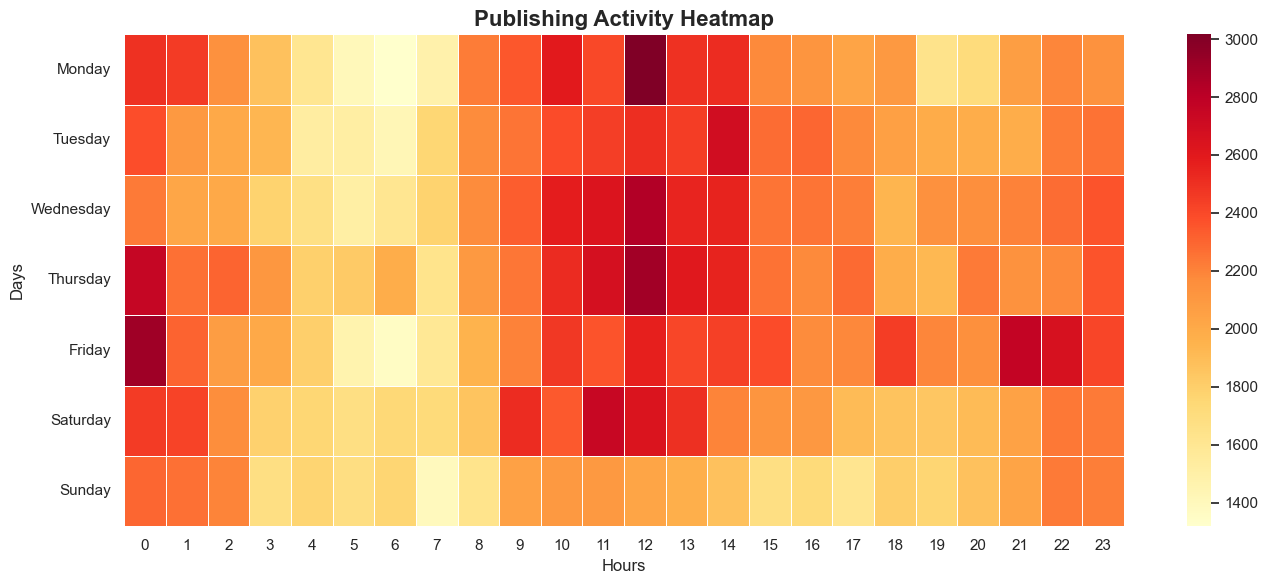

In [13]:
activity_matrix = tg_rows.groupby(["day_of_week", "hour"]).size().unstack(fill_value=0)

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
activity_matrix = activity_matrix.reindex(days_order)

plt.figure(figsize=(14, 6))
sns.heatmap(activity_matrix, cmap="YlOrRd", annot=False, linewidths=0.5)
plt.title("Publishing Activity Heatmap", fontsize=16, fontweight="bold")
plt.xlabel("Hours")
plt.ylabel("Days")
plt.tight_layout()
plt.show()

### Text Length Analysis

Telegram message length distribution -- typical structure of Telegram alerts.

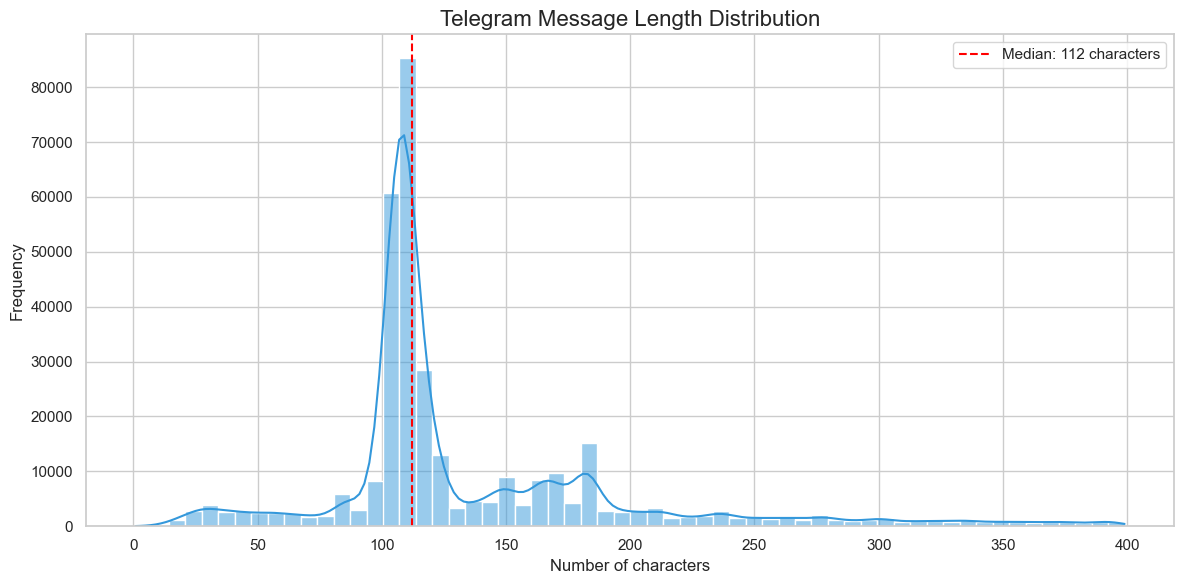

In [14]:
plt.figure(figsize=(12, 6))
sns.histplot(data=tg_rows[tg_rows["text_length"] < 400], x="text_length", bins=60, color="#3498db", kde=True)

median_len = tg_rows["text_length"].median()
plt.axvline(median_len, color="red", linestyle="--", label=f"Median: {median_len:.0f} characters")

plt.title("Telegram Message Length Distribution", fontsize=16)
plt.xlabel("Number of characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### TF-IDF Keyword Analysis

Most important words in Telegram messages via TF-IDF (exploratory only -- not persisted into the final feature table).

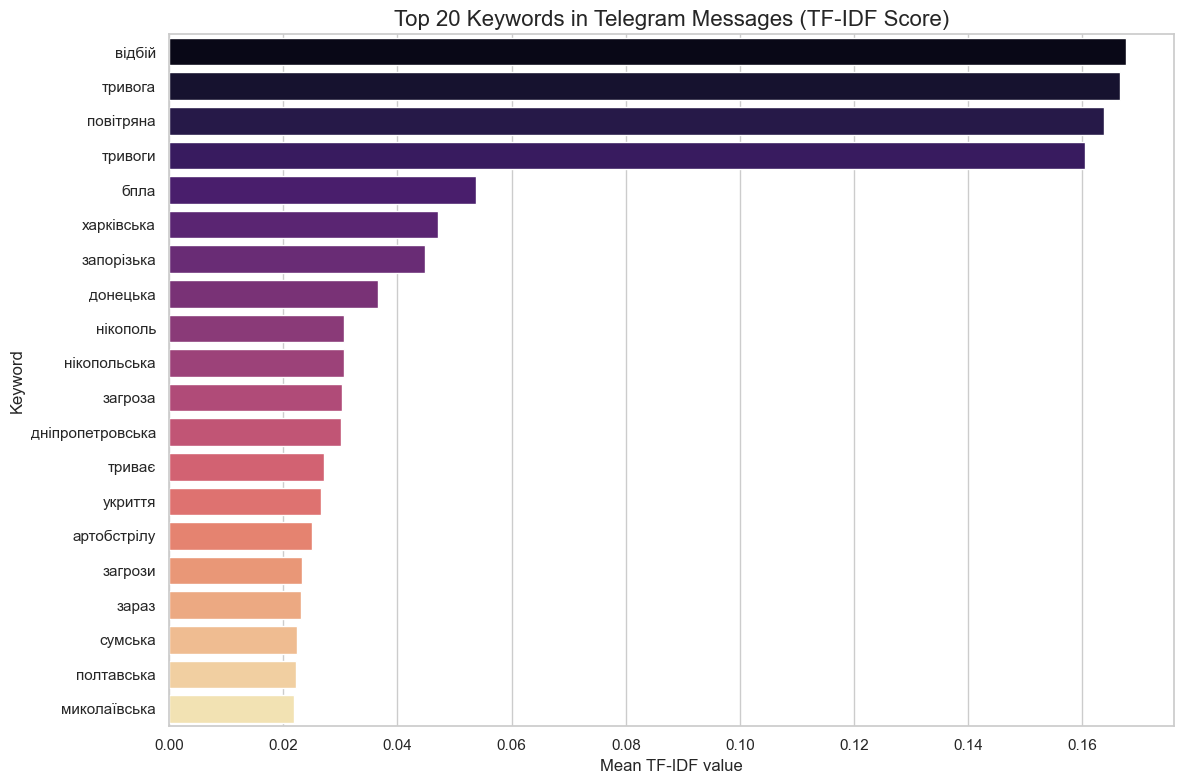

In [15]:
sample_texts = tg_rows["clean_text"].dropna()

tfidf = TfidfVectorizer(max_features=20)
tfidf_matrix = tfidf.fit_transform(sample_texts)

mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
words = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame({
    "Word": words,
    "TF-IDF Score": mean_tfidf,
}).sort_values(by="TF-IDF Score", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x="TF-IDF Score", y="Word", data=tfidf_df, palette="magma")
plt.title("Top 20 Keywords in Telegram Messages (TF-IDF Score)", fontsize=16)
plt.xlabel("Mean TF-IDF value", fontsize=12)
plt.ylabel("Keyword", fontsize=12)
plt.tight_layout()
plt.show()

### Threat Keyword Trends

How often certain threat types appear over time.

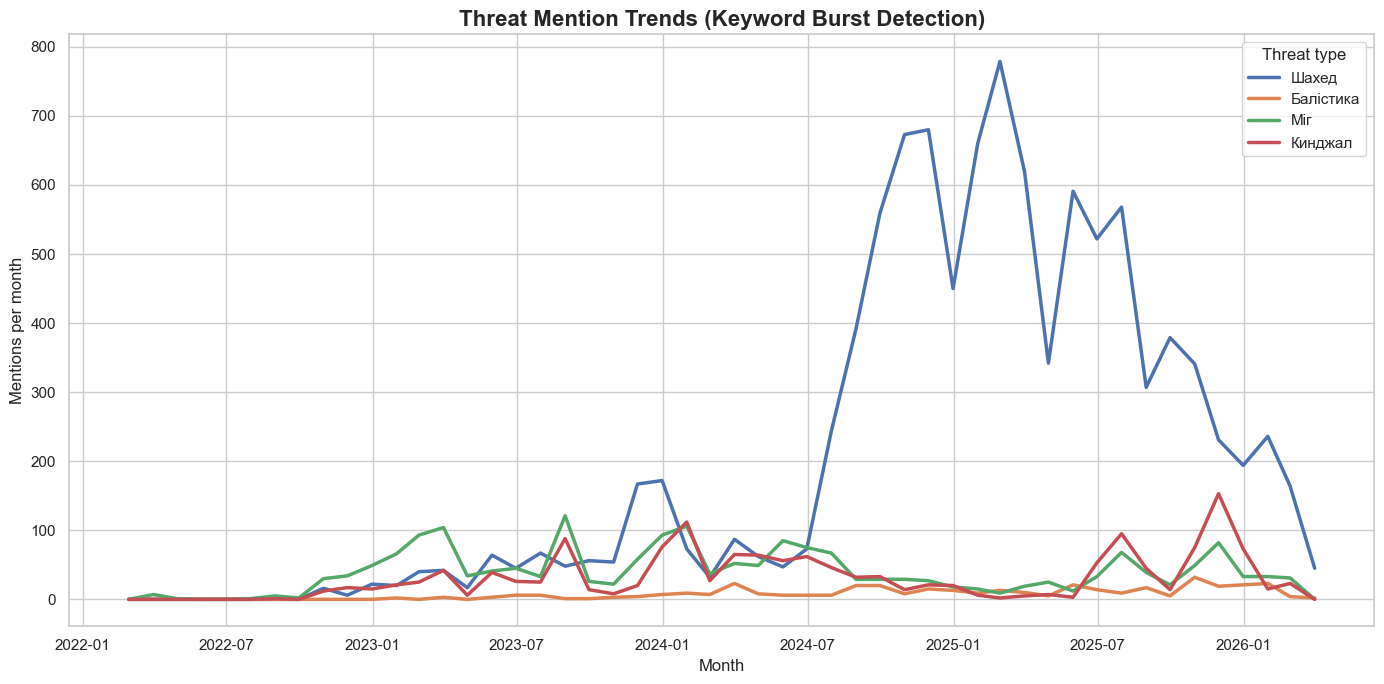

In [16]:
target_words = ["шахед", "балістика", "міг", "кинджал"]
for word in target_words:
    tg_rows[word] = tg_rows["clean_text"].apply(lambda x: 1 if word in str(x) else 0)

trends_df = tg_rows.set_index("date")[target_words].resample("ME").sum()

plt.figure(figsize=(14, 7))
for word in target_words:
    plt.plot(trends_df.index, trends_df[word], linewidth=2.5, label=word.capitalize())

plt.title("Threat Mention Trends (Keyword Burst Detection)", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Mentions per month", fontsize=12)
plt.legend(title="Threat type")
plt.tight_layout()
plt.show()

### Message Activity Dynamics

How many Telegram messages appear over time.

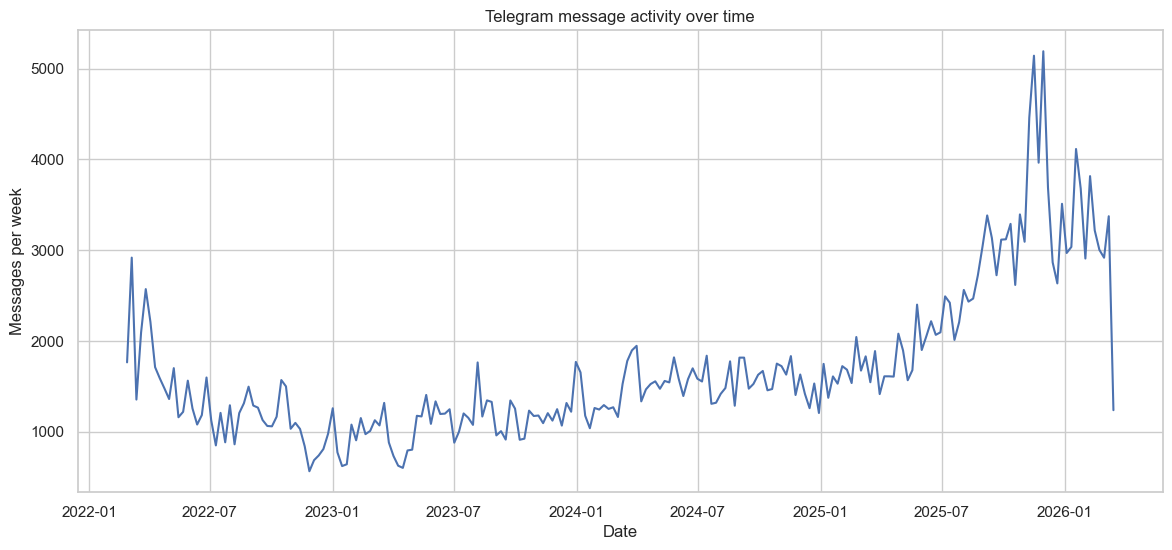

In [17]:
weekly_counts = tg_rows.resample("W", on="date").size()

plt.figure(figsize=(14, 6))
plt.plot(weekly_counts.index, weekly_counts.values)
plt.title("Telegram message activity over time")
plt.xlabel("Date")
plt.ylabel("Messages per week")
plt.show()

## Lemmatization (Phase 2)

`тривога`/`тривоги`/`тривозі` are different tokens to a naive `CountVectorizer` -- wasted vocabulary budget on surface-form duplicates instead of distinct concepts. We lemmatize at the unique-word (type) level, not per-message -- the corpus vocabulary is a few tens of thousands of unique words, orders of magnitude cheaper than parsing every occurrence. **This is preprocessing for the embeddings step below, not a kept feature by itself** -- the goal is cleaner text going into the sentence-embedding model, not a `lemma_*` column in the final table.

In [18]:
@lru_cache(maxsize=None)
def lemmatize_word(word: str) -> str:
    """Best-scoring lemma across both uk and ru dictionaries (pymorphy3 exposes
    a confidence `.score` per parse)."""
    parse_uk = morph_uk.parse(word)[0]
    parse_ru = morph_ru.parse(word)[0]
    best = parse_uk if parse_uk.score >= parse_ru.score else parse_ru
    return best.normal_form


def lemmatize_text(text: str) -> str:
    return " ".join(lemmatize_word(w) for w in text.split())


vocab = set(" ".join(tg_rows["clean_text"]).split())
print(f"corpus vocabulary: {len(vocab)} unique words")

alarm_variants = sorted(w for w in vocab if w.startswith("тривог"))
print(f"surface forms of 'тривога' before lemmatization: {alarm_variants}")
print(f"-> collapse to: {sorted({lemmatize_word(w) for w in alarm_variants})}")

corpus vocabulary: 134049 unique words
surface forms of 'тривога' before lemmatization: ['тривог', 'тривога', 'тривогакомендантська', 'тривогам', 'тривогами', 'тривогах', 'тривоги', 'тривогивідбої', 'тривогою', 'тривогу']
-> collapse to: ['тривога', 'тривогакомендантська', 'тривогивідбої']


In [19]:
tg_rows["lemma_text"] = tg_rows["clean_text"].apply(lemmatize_text)

lemma_vocab = set(" ".join(tg_rows["lemma_text"]).split())
print(f"vocabulary: {len(vocab)} surface forms -> {len(lemma_vocab)} lemmas "
      f"({(1 - len(lemma_vocab) / len(vocab)):.1%} reduction)")

vocabulary: 134049 surface forms -> 64904 lemmas (51.6% reduction)


## National hourly feature table

Hourly aggregation (unchanged in spirit from `eda_telegram.ipynb`), built from `tg_rows` instead of a second parallel cleaning pass. **No bag-of-words / keyword-group columns here** -- per the trimmed feature-engineering scope, the only text-derived hourly signal is `combined_lemma_text`, which feeds the embeddings step next. `messages_count`, `has_threat_sum`, and the rolling/diff features below are basic aggregates, kept as foundational features.

In [20]:
national_hourly = (
    tg_rows.groupby("hour_rounded")
    .agg(
        messages_count=("text", "count"),
        has_threat_sum=("has_threat_keyword", "sum"),
        combined_lemma_text=("lemma_text", lambda x: " ".join(x)),
    )
    .reset_index()
)

full_range = pd.date_range(
    start=national_hourly["hour_rounded"].min(),
    end=national_hourly["hour_rounded"].max(),
    freq="h",
)
national_hourly = (
    national_hourly
    .set_index("hour_rounded")
    .reindex(full_range)
    .fillna({"messages_count": 0, "has_threat_sum": 0, "combined_lemma_text": ""})
    .rename_axis("hour_rounded")
    .reset_index()
)

print(f"national hourly rows: {national_hourly.shape[0]}")
national_hourly.head(3)

national hourly rows: 35441


,hour_rounded,messages_count,has_threat_sum,combined_lemma_text
0,2022-02-24 02:00:00+02:00,1.0,0.0,совбез оон провести экстренный заседание украи...
1,2022-02-24 03:00:00+02:00,0.0,0.0,
2,2022-02-24 04:00:00+02:00,1.0,0.0,путина прямо сейчас заявить начало проведение ...


In [21]:
national_hourly["msg_count_last_3h"] = national_hourly["messages_count"].rolling(3, min_periods=1).sum()
national_hourly["msg_count_last_24h"] = national_hourly["messages_count"].rolling(24, min_periods=1).sum()
national_hourly["threat_diff_1h"] = national_hourly["has_threat_sum"].diff().fillna(0)

national_hourly.head(3)

,hour_rounded,messages_count,has_threat_sum,combined_lemma_text,msg_count_last_3h,msg_count_last_24h,threat_diff_1h
0,2022-02-24 02:00:00+02:00,1.0,0.0,совбез оон провести экстренный заседание украи...,1.0,1.0,0.0
1,2022-02-24 03:00:00+02:00,0.0,0.0,,1.0,1.0,0.0
2,2022-02-24 04:00:00+02:00,1.0,0.0,путина прямо сейчас заявить начало проведение ...,2.0,2.0,0.0


## Semantic embeddings + PCA (95% variance)

`CountVectorizer` bag-of-words only ever counts exact tokens -- it can't tell that "укриття" and "сирена" are related concepts. We add a multilingual sentence embedding on the hourly `combined_lemma_text`, PCA-compressed to the number of components needed to retain **at least 95% of variance** (mirrors the pattern `isw_features.py` already uses for ISW reports: encode -> PCA -> `*_PCA{i}` columns). Embedding runs on the ~35k hourly rows, not all 357k messages -- tractable on CPU.

**Change from the source notebook:** the original prototype used a fixed `n_components=10` (68.2% explained variance). Per the requirement to retain 95%+ variance, `PCA` is switched to a variance-ratio threshold (`n_components=0.95`), so sklearn picks however many components are needed.

In [22]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
hourly_texts = national_hourly["combined_lemma_text"].fillna("")
embeddings = embed_model.encode(hourly_texts.tolist(), batch_size=64, show_progress_bar=True)
print("raw embedding matrix:", embeddings.shape)

pca_emb = PCA(n_components=0.95, random_state=SEED)
emb_pca = pca_emb.fit_transform(embeddings)
emb_pca_cols = [f"emb_PCA{i+1}" for i in range(emb_pca.shape[1])]
national_hourly = pd.concat(
    [national_hourly.reset_index(drop=True), pd.DataFrame(emb_pca, columns=emb_pca_cols)], axis=1
)

print(f"components for >=95% variance: {pca_emb.n_components_}")
print(f"explained variance ({pca_emb.n_components_} components): {pca_emb.explained_variance_ratio_.sum():.1%}")
national_hourly[["hour_rounded", "messages_count"] + emb_pca_cols[:3]].head(3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/554 [00:00<?, ?it/s]

raw embedding matrix: (35441, 384)


components for >=95% variance: 93
explained variance (93 components): 95.0%


,hour_rounded,messages_count,emb_PCA1,emb_PCA2,emb_PCA3
0,2022-02-24 02:00:00+02:00,1.0,0.406635,-0.501822,0.917420
1,2022-02-24 03:00:00+02:00,0.0,2.855417,2.014691,-0.033921
2,2022-02-24 04:00:00+02:00,1.0,-0.177892,-0.961755,0.975808


### Visual sanity check

Compare `emb_PCA1`/`emb_PCA2` between quiet hours (no messages) and active threat hours (`has_threat_sum > 0`) -- components should visibly separate, not look like noise around the same center.

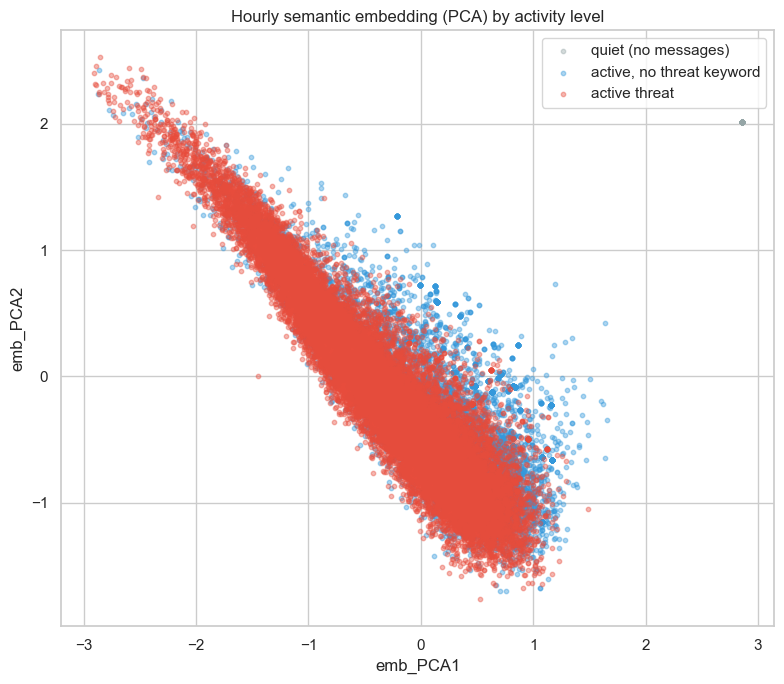

emb_PCA1                emb_PCA2              
                               mean           std      mean           std
hour_category                                                            
active threat             -0.318443  6.861576e-01 -0.102179  7.226720e-01
active, no threat keyword  0.075599  6.848118e-01 -0.257432  6.615358e-01
quiet (no messages)        2.855416  2.364424e-07  2.014691  1.237220e-07

In [23]:
def hour_category(row):
    if row["messages_count"] == 0:
        return "quiet (no messages)"
    if row["has_threat_sum"] > 0:
        return "active threat"
    return "active, no threat keyword"


national_hourly["hour_category"] = national_hourly.apply(hour_category, axis=1)

palette = {
    "quiet (no messages)": "#95a5a6",
    "active, no threat keyword": "#3498db",
    "active threat": "#e74c3c",
}
order = list(palette.keys())

fig, ax = plt.subplots(figsize=(8, 7))
for cat in order:
    subset = national_hourly[national_hourly["hour_category"] == cat]
    ax.scatter(subset["emb_PCA1"], subset["emb_PCA2"], s=10, alpha=0.4, color=palette[cat], label=cat)
ax.set_xlabel("emb_PCA1")
ax.set_ylabel("emb_PCA2")
ax.set_title("Hourly semantic embedding (PCA) by activity level")
ax.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()

national_hourly.groupby("hour_category")[["emb_PCA1", "emb_PCA2"]].agg(["mean", "std"])

## Leakage-prevention shift

Shift every feature column (but not the timestamp) by 1 hour so a row's features only use information available up to and including the previous hour -- same pattern both source notebooks used. Selecting columns by name/prefix (rather than a hardcoded list) survives future vocabulary/component-count changes -- a hardcoded list is exactly what broke in `telegram_features.py` when its vectorizer vocabulary changed.

In [24]:
SHIFT_PREFIXES = ("emb_",)
NAMED_SHIFT_COLS = ["messages_count", "has_threat_sum", "msg_count_last_3h", "msg_count_last_24h", "threat_diff_1h"]


def dynamic_cols_to_shift(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c.startswith(SHIFT_PREFIXES) or c in NAMED_SHIFT_COLS]


cols_to_shift = dynamic_cols_to_shift(national_hourly)
national_hourly[cols_to_shift] = national_hourly[cols_to_shift].shift(1)
national_hourly = national_hourly.drop(columns=["combined_lemma_text", "hour_category"]).fillna(0)

print(f"shifted columns: {len(cols_to_shift)}")
national_hourly.head(3)

shifted columns: 98


,hour_rounded,messages_count,has_threat_sum,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,emb_PCA1,emb_PCA2,emb_PCA3,emb_PCA4,emb_PCA5,emb_PCA6,emb_PCA7,emb_PCA8,emb_PCA9,emb_PCA10,emb_PCA11,emb_PCA12,emb_PCA13,emb_PCA14,emb_PCA15,emb_PCA16,emb_PCA17,emb_PCA18,emb_PCA19,emb_PCA20,emb_PCA21,emb_PCA22,emb_PCA23,emb_PCA24,emb_PCA25,emb_PCA26,emb_PCA27,emb_PCA28,emb_PCA29,emb_PCA30,emb_PCA31,emb_PCA32,emb_PCA33,emb_PCA34,emb_PCA35,emb_PCA36,emb_PCA37,emb_PCA38,emb_PCA39,emb_PCA40,emb_PCA41,emb_PCA42,emb_PCA43,emb_PCA44,emb_PCA45,emb_PCA46,emb_PCA47,emb_PCA48,emb_PCA49,emb_PCA50,emb_PCA51,emb_PCA52,emb_PCA53,emb_PCA54,emb_PCA55,emb_PCA56,emb_PCA57,emb_PCA58,emb_PCA59,emb_PCA60,emb_PCA61,emb_PCA62,emb_PCA63,emb_PCA64,emb_PCA65,emb_PCA66,emb_PCA67,emb_PCA68,emb_PCA69,emb_PCA70,emb_PCA71,emb_PCA72,emb_PCA73,emb_PCA74,emb_PCA75,emb_PCA76,emb_PCA77,emb_PCA78,emb_PCA79,emb_PCA80,emb_PCA81,emb_PCA82,emb_PCA83,emb_PCA84,emb_PCA85,emb_PCA86,emb_PCA87,emb_PCA88,emb_PCA89,emb_PCA90,emb_PCA91,emb_PCA92,emb_PCA93
0,2022-02-24 02:00:00+02:00,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
1,2022-02-24 03:00:00+02:00,1.0,0.0,1.0,1.0,0.0,0.406635,-0.501822,0.917420,-0.184512,0.562947,1.249814,0.873781,0.132899,-0.204570,0.066673,-0.007306,-0.050513,0.224365,0.371654,0.282754,0.063748,0.152151,-0.074176,-0.348735,0.047526,0.378173,0.122115,-0.040214,-0.524072,0.187051,0.126091,-0.162056,-0.036373,0.004233,0.050294,-0.041582,0.084019,0.461039,-0.078441,0.007834,0.290540,-0.022730,-0.067845,-0.159046,-0.312362,0.046951,-0.002612,-0.342077,0.262083,-0.392578,0.188283,-0.217425,-0.145521,0.049652,0.180832,0.080133,-0.075648,-0.172621,0.115783,-0.102728,-0.039737,-0.197980,-0.003432,-0.080942,-0.183011,0.239229,0.034519,0.007340,-0.049575,0.145770,-0.035281,0.170444,0.091956,0.203100,0.145157,0.040189,-0.039133,0.150925,-0.176856,-0.068950,-0.020337,0.177605,0.042585,0.089170,-0.114031,-0.003779,0.214837,-0.080002,-0.089210,-0.162769,0.026901,0.043738,0.001623,-0.167325,0.064726,-0.059814,-0.218463,0.06622
2,2022-02-24 04:00:00+02:00,0.0,0.0,1.0,1.0,0.0,2.855417,2.014691,-0.033921,0.070262,0.197121,0.080836,-0.079601,-0.052363,0.040182,-0.038570,0.028980,0.029103,0.033939,0.005957,0.033444,0.001125,-0.012028,-0.002540,-0.005826,0.021341,-0.023227,-0.006001,0.017131,0.005900,0.001591,-0.002881,0.005533,-0.002798,0.000021,-0.001626,-0.004448,0.000035,-0.000014,-0.005234,0.007364,-0.001388,0.007265,0.008164,-0.000445,0.011108,0.004954,-0.007226,-0.005191,0.003634,-0.000354,0.000489,-0.000181,-0.001488,-0.000502,0.000703,-0.002371,-0.002520,-0.000118,0.000392,0.001537,0.001568,0.005048,-0.002196,-0.001054,0.006405,-0.002510,0.004178,0.003607,-0.003512,-0.001091,-0.001685,-0.001416,-0.000627,0.000138,-0.002591,-0.002382,0.003620,0.000964,0.003685,0.002406,-0.000371,0.000518,-0.001066,-0.001106,-0.001576,-0.002964,-0.000957,0.000022,-0.000132,-0.001442,0.001069,0.002337,-0.000586,0.001247,0.000281,-0.001026,-0.000986,0.00167


## Save prepared datasets

Two tables, matching how `merge_data.py` should consume them going forward:
- `national_hourly` -- one row per hour (`messages_count`, `has_threat_sum`, rolling/diff features, `emb_PCA*`), merged on `time` only.
- `region_hourly` -- one row per `(region_id, hour)` (`region_mentions_count`, `region_threat_count`), merged on `["region_id", "time"]` -- this is what lets region-tagged features actually reach the model instead of being broadcast nationally.

No joblib vectorizer artifact this time -- no `CountVectorizer` is fitted in this notebook.

In [25]:
national_path = Path("data/telegram/telegram_hourly_features_v2.csv")
region_path = Path("data/telegram/telegram_region_hourly_v2.csv")
national_path.parent.mkdir(parents=True, exist_ok=True)

national_hourly.to_csv(national_path, index=False)
region_hourly.to_csv(region_path, index=False)

print(f"saved {national_hourly.shape} -> {national_path}")
print(f"saved {region_hourly.shape} -> {region_path}")

saved (35441, 99) -> data\telegram\telegram_hourly_features_v2.csv
saved (152269, 4) -> data\telegram\telegram_region_hourly_v2.csv


## Results / Conclusion

- **Bilingual gap:** confirmed but small -- see the uk-vs-ru coverage numbers above.
- **Regions frequent enough to tag:** confirmed -- see the "rows with >=1 region tag" share and the top-regions chart.
- **Lemmatization shrinks vocabulary:** confirmed -- see the surface-form -> lemma reduction % above.
- **Region mentions correlate with real alarms:** `P(alarm | region+threat mention)` is meaningfully above the base rate (see the cross-check cell).
- **Embeddings + PCA:** retaining >=95% of variance takes noticeably more components than the original prototype's fixed 10 (which only reached 68.2%) -- see the printed component count above.
- **Bonus finding:** `telegram_features.py`'s `_build_hourly_dataframe()` crashes on the Oct-2022 DST fall-back when run over the full history -- a latent production bug, undiscovered until this notebook ran the pipeline end-to-end on all years of data at once.
- **Dropped from the original prototypes, per this notebook's scope:** the 15-token and 150-token `CountVectorizer` bag-of-words, and the bilingual `kw_*` per-keyword counters -- region tagging + embeddings/PCA supersede them as the kept text-signal features.

**Next steps:** if these results hold up, productionize `tag_regions`/`ALIAS_TO_REGIONS` into `app/core/features/region_gazetteer.py` and the embedding step into `app/core/features/text_embeddings.py`, and update `merge_data.py` to merge `region_hourly` on `["region_id", "time"]` alongside the existing national `time`-only merge.